# || NEMO Additional Gastruloid Analysis Modules ||
© Konstantinos Andreadis 2024 (PhD in the Roux Lab & Salbreux Lab at UNIGE, Switzerland)

please cite: K.Andreadis _et al._ "NEMO: Mesh-Based Tangential Nematic Field, Defect, and Morphology Analysis in Volumetric Microscopy Data" (2026, _in preparation_)

In [1]:
from importlib import reload

# Import custom scripts
from scripts import analysis, datahandler, visuals, simulation

for module in (analysis, datahandler, visuals, simulation):
    reload(module)

# Import python essentials
import trimesh
import scipy.spatial

In [ ]:
visuals.view_mesh([])

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass

# ==== Choose Channel ====
img_path = '/Users/andreadi/Downloads/20260306_nuclei-flows/Livenuc15mingas112h002.nd2 - Livenuc15mingas112h002.nd2 (series 5).tif_aligned_nuclei_masks.tif'
dims = analysis.load_img_dimensions(img_path)
num_timepoints = dims["T"]
num_channels = dims["C"]

video_stack = []
for c_i in range(num_channels):
    time_stack = []
    for t_i in range(num_timepoints):
        # ==== Load Image ====
        img_load = analysis.load_img_virtual(path=img_path, t_sel_idx=t_i,
                                             c_sel_idx=c_i, reduce_xy=1, reduce_z=1, norm_vals=False,
                                             custom_scaling=None, custom_unit="um")
        img_raw_i, img_dim_i, img_scale_i, img_unit_i = img_load
        time_stack.append(img_raw_i)
    time_stack = np.stack(time_stack, axis=0)
    video_stack.append(time_stack)

# ==== 3D Render Image ====
mask_evolution = np.array(video_stack)[0]
# --- 1. CONFIGURATION ---
microns_per_pixel = img_scale_i
dt = 15.0  # minutes

# --- 2. EXTRACTION ---
trajectories = {}
num_t, num_z, num_y, num_x = mask_evolution.shape

for t in range(num_t):
    frame = mask_evolution[t]
    labels = np.unique(frame)
    labels = labels[labels != 0]

    if len(labels) == 0: continue

    centers = center_of_mass(frame, labels=frame, index=labels)
    if len(labels) == 1: centers = [centers]

    for lbl, coords in zip(labels, centers):
        if lbl not in trajectories: trajectories[lbl] = []
        # Store scaled coordinates (physical units)
        trajectories[lbl].append(np.array(coords) * microns_per_pixel)

# Only keep trajectories that exist for at least 5 frames for better slope fitting
trajectories = {k: np.array(v) for k, v in trajectories.items() if len(v) > 5}


# --- 3. ANALYSIS (MSD) ---
def get_msd(traj):
    n = len(traj)
    msd = np.zeros(n)
    for tau in range(1, n):
        diffs = traj[tau:] - traj[:-tau]
        msd[tau] = np.mean(np.sum(diffs ** 2, axis=1))
    return msd


all_msds = {lbl: get_msd(pos) for lbl, pos in trajectories.items()}

>> Loading /Users/andreadi/Downloads/20260306_nuclei-flows/Livenuc15mingas112h002.nd2 - Livenuc15mingas112h002.nd2 (series 5).tif_aligned_nuclei_masks.tif...
T = 25, Z = 33, C = 1, Y = 277, X = 277
>> Loading /Users/andreadi/Downloads/20260306_nuclei-flows/Livenuc15mingas112h002.nd2 - Livenuc15mingas112h002.nd2 (series 5).tif_aligned_nuclei_masks.tif...
Found 4D TZYX Hyperstack | (25, 33, 277, 277) | 253.21 MB !
Found xscale = 1.0, yscale = 1.0 !
Z spacing absent... using default 1.0 instead !
Found image scale = (1.0, 1.0, 1.0) !
>> Overwriting unit with um...
>> Selecting Z-Stack at T=0 C=0 ...
Loaded T=0 C=0 Z-stack (10.13 MB) !
>> Loading /Users/andreadi/Downloads/20260306_nuclei-flows/Livenuc15mingas112h002.nd2 - Livenuc15mingas112h002.nd2 (series 5).tif_aligned_nuclei_masks.tif...
Found 4D TZYX Hyperstack | (25, 33, 277, 277) | 253.21 MB !
Found xscale = 1.0, yscale = 1.0 !
Z spacing absent... using default 1.0 instead !
Found image scale = (1.0, 1.0, 1.0) !
>> Overwriting unit w

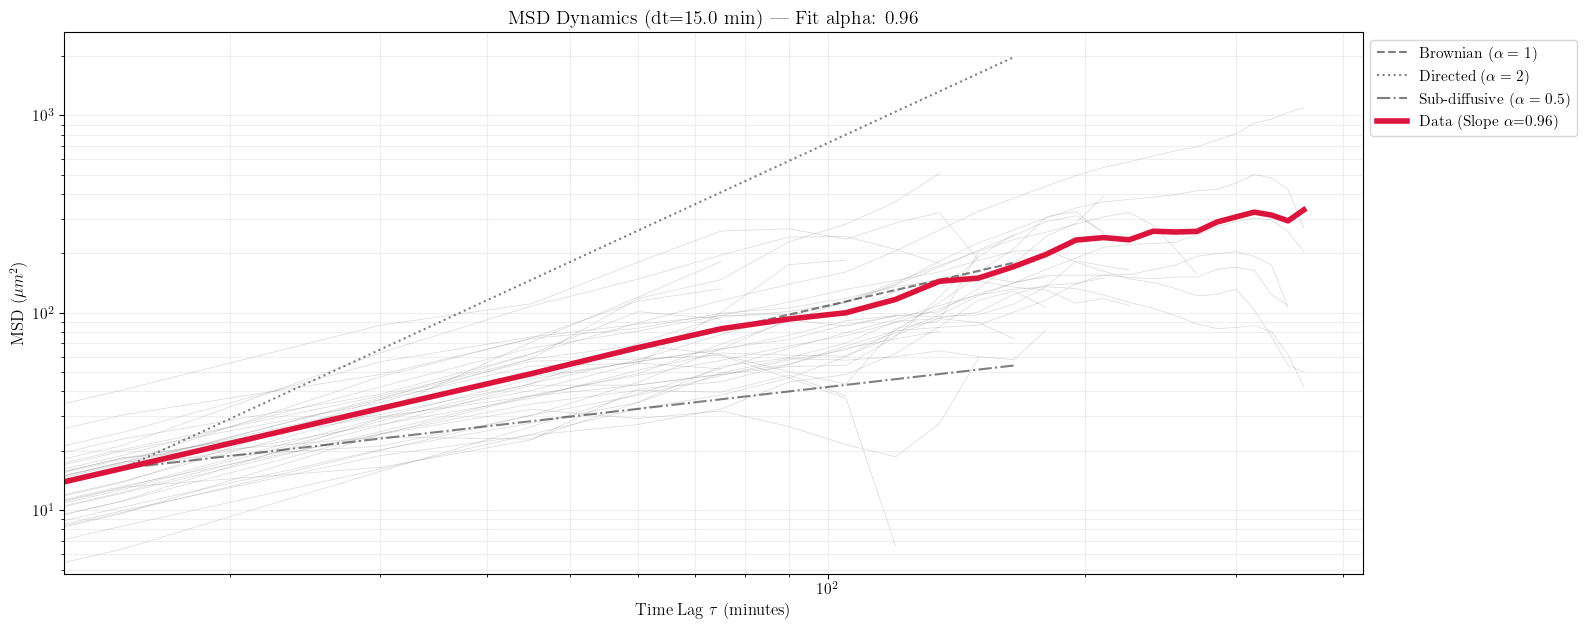

<Figure size 640x480 with 0 Axes>

In [10]:

# --- 4. PLOTTING ---
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 3)
# A. MSD Plot (Log-Log)
ax_msd = fig.add_subplot(gs[1, :])
max_len = max([len(m) for m in all_msds.values()])
lags = np.arange(max_len) * dt

# Plot individual lines
for msd in all_msds.values():
    ax_msd.loglog(np.arange(len(msd)) * dt, msd, color='gray', alpha=0.3, lw=0.5)

# Calculate Ensemble Average
avg_msd = np.zeros(max_len)
counts = np.zeros(max_len)
for m in all_msds.values():
    avg_msd[:len(m)] += m
    counts[:len(m)] += 1
avg_msd /= np.where(counts > 0, counts, 1)

# Fit slope (Alpha) on log-log data
fit_idx = slice(1, max_len // 2)
log_lags = np.log(lags[fit_idx])
log_msd = np.log(avg_msd[fit_idx])
alpha, intercept = np.polyfit(log_lags, log_msd, 1)

# Overlay Reference Slopes - USING RAW STRINGS (r"...")
ref_x = lags[fit_idx]
start_pt = avg_msd[1]
ax_msd.loglog(ref_x, start_pt * (ref_x / ref_x[0]) ** 1.0, 'k--', alpha=0.5, label=r'Brownian ($\alpha=1$)')
ax_msd.loglog(ref_x, start_pt * (ref_x / ref_x[0]) ** 2.0, 'k:', alpha=0.5, label=r'Directed ($\alpha=2$)')
ax_msd.loglog(ref_x, start_pt * (ref_x / ref_x[0]) ** 0.5, 'k-.', alpha=0.5, label=r'Sub-diffusive ($\alpha=0.5$)')

# Plot Average - USING RAW STRINGS
ax_msd.loglog(lags, avg_msd, color='crimson', lw=4, label=r'Data (Slope $\alpha$=' + f'{alpha:.2f})')

ax_msd.set_title(f"MSD Dynamics (dt={dt} min) | Fit alpha: {alpha:.2f}")
ax_msd.set_xlabel(r"Time Lag $\tau$ (minutes)")
ax_msd.set_ylabel(r"MSD ($\mu m^2$)")
ax_msd.grid(True, which="both", ls="-", alpha=0.2)
ax_msd.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Final layout fix
fig.tight_layout()
plt.show()

# B. Orthogonal Projections
views = [
    {"name": "XY (Top)", "axes": (0, 1), "x_idx": 2, "y_idx": 1},
    {"name": "XZ (Side)", "axes": (0, 2), "x_idx": 2, "y_idx": 0},
    {"name": "YZ (Front)", "axes": (0, 3), "x_idx": 1, "y_idx": 0}
]

for i, v in enumerate(views):
    ax = fig.add_subplot(gs[0, i])
    mip = np.max(mask_evolution > 0, axis=v["axes"])
    ax.imshow(mip, cmap='magma', origin='lower', alpha=0.3)

    for path in trajectories.values():
        # Divide by microns_per_pixel to map back to pixel indices for plotting
        px_path = path / microns_per_pixel
        ax.plot(px_path[:, v["x_idx"]], px_path[:, v["y_idx"]], color='white', lw=1, alpha=0.7)
        ax.scatter(px_path[-1, v["x_idx"]], px_path[-1, v["y_idx"]], color='cyan', s=5, zorder=5)

    ax.set_title(v["name"])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [18]:
import napari
import numpy as np

# 1. Convert masks to integer
mask_int = mask_evolution.astype(np.uint16)

# 2. Prepare the track data [ID, T, Z, Y, X]
track_data = []
for lbl, path in trajectories.items():
    pixel_path = path / microns_per_pixel
    for t_idx, coords in enumerate(pixel_path):
        # Order: ID, T, Z, Y, X
        row = [lbl, t_idx, coords[0], coords[1], coords[2]]
        track_data.append(row)

tracks = np.array(track_data)

# 3. Launch Napari
viewer = napari.Viewer()

# Add the integer masks
viewer.add_labels(mask_int, name='Nuclei Masks', opacity=0.4)

# Add the Traces using only the most standard arguments
# We use 'color_by' or 'edge_color' depending on version;
# 'label' is the internal feature name Napari gives the first column (ID)
viewer.add_tracks(
    tracks,
    name='Nuclei Traces',
    tail_length=15,
    tail_width=2,
    colormap='viridis'
)

# Switch to 3D view
viewer.dims.ndisplay = 3
napari.run()

In [ ]:
img_path = '/Users/andreadi/Downloads/20260306_nuclei-flows/Livenuc15mingas112h002.nd2 - Livenuc15mingas112h002.nd2 (series 5).tif_aligned.tif'
# ==== Choose Channel ====
dims = analysis.load_img_dimensions(img_path)
num_timepoints = dims["T"]
num_channels = dims["C"]

video_stack = []
for c_i in range(num_channels):
    time_stack = []
    for t_i in range(num_timepoints):
        # ==== Load Image ====
        img_load = analysis.load_img_virtual(path=img_path, t_sel_idx=t_i,
                                             c_sel_idx=c_i, reduce_xy=1, reduce_z=1, norm_vals=False,
                                             custom_scaling=None, custom_unit="um")
        img_raw_i, img_dim_i, img_scale_i, img_unit_i = img_load
        time_stack.append(img_raw_i)
    time_stack = np.stack(time_stack, axis=0)
    video_stack.append(time_stack)
visuals.view_img(img_list=video_stack, scale=img_scale_i, color_list=["red", "grey"], opacity_list=[1.0, 0.4])

In [ ]:
img_path = '/Users/andreadi/Downloads/20260306_nuclei-flows/Livenuc15mingas112h002.nd2 - Livenuc15mingas112h002.nd2 (series 2).tif'
# ==== Choose Channel ====
dims = analysis.load_img_dimensions(img_path)
num_timepoints = dims["T"]
num_channels = dims["C"]

video_stack = []
for c_i in range(num_channels):
    time_stack = []
    for t_i in range(num_timepoints):
        # ==== Load Image ====
        img_load = analysis.load_img_virtual(path=img_path, t_sel_idx=t_i,
                                             c_sel_idx=c_i, reduce_xy=1, reduce_z=1, norm_vals=False,
                                             custom_scaling=None, custom_unit="um")
        img_raw_i, img_dim_i, img_scale_i, img_unit_i = img_load
        time_stack.append(img_raw_i)
    time_stack = np.stack(time_stack, axis=0)
    video_stack.append(time_stack)
img_array = np.array(video_stack)
visuals.plot_img(np.max(video_stack, axis=2)[1], scale=img_scale_i, unit=img_unit_i, max_proj=True, cmap='Greys_r')
C, T, Z, Y, X = img_array.shape
orig_dtype = img_array.dtype
aligned_array = np.zeros_like(img_array)

In [ ]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
from skimage.filters import sobel, threshold_otsu, gaussian
from skimage.measure import regionprops, label
from skimage.morphology import remove_small_objects
from skimage.transform import EuclideanTransform, warp
from scipy.ndimage import binary_fill_holes
import os


def get_mask_props(bf_mip):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        # if np.any(bf_mip == 0.0):
        #     bf_mip = analysis.thresh_img(bf_mip, thresh=180, inverse=False, keep_values_above=True)
        plt.imshow(bf_mip)
        plt.colorbar()
        plt.show()
        edges = sobel(gaussian(bf_mip, sigma=5))
        thresh = threshold_otsu(edges)
        mask = edges > 0.5 * thresh
        mask = binary_fill_holes(mask)
        mask = remove_small_objects(mask, min_size=10000)
        lbl = label(mask)
        props = regionprops(lbl)
        if not props: return None, mask
        return max(props, key=lambda p: p.area), mask


def debug_alignment(t, bf_mip, mask, props, t_inv):
    plt.figure(figsize=(15, 5))

    # 1. Raw Input
    plt.subplot(1, 3, 1)
    plt.imshow(bf_mip, cmap='gray')
    plt.title(f"T={t} Raw Input")

    # 2. Segmentation + PCA Axis
    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='magma')
    if props:
        y0, x0 = props.centroid
        angle = props.orientation
        # Corrected trig: sin for X, cos for Y because 0 is vertical
        x1 = x0 + np.sin(angle) * 0.5 * props.major_axis_length
        y1 = y0 + np.cos(angle) * 0.5 * props.major_axis_length
        plt.plot((x0, x1), (y0, y1), '-r', lw=2.5)
        plt.plot(x0, y0, '.g', markersize=15)
    plt.title("Mask + PCA Orientation")

    # 3. Transformed (Aligned) Result
    plt.subplot(1, 3, 3)
    aligned_bf = warp(bf_mip, t_inv, preserve_range=True, order=1)
    plt.imshow(aligned_bf, cmap='gray')
    plt.title("Aligned Frame")

    plt.tight_layout()
    plt.show()


ref_props, _ = get_mask_props(np.mean(img_array[1, 0], axis=0))
if ref_props is None: raise ValueError("Segmentation failed at T=0. Check Brightfield.")
ref_cy, ref_cx = ref_props.centroid
ref_angle = ref_props.orientation
last_angle = ref_angle
t_inv = np.eye(3)
for t in range(T):
    print(f">> Aligning {t + 1}/{T}...")
    bf_mip = np.mean(img_array[1, t], axis=0)
    props, mask = get_mask_props(bf_mip)

    if props is not None:
        curr_cy, curr_cx = props.centroid
        curr_angle = props.orientation
        while (curr_angle - last_angle) > np.pi / 2: curr_angle -= np.pi
        while (curr_angle - last_angle) < -np.pi / 2: curr_angle += np.pi
        last_angle = curr_angle

        # Matrix composition
        t1 = EuclideanTransform(translation=(-curr_cx, -curr_cy))
        t2 = EuclideanTransform(rotation=ref_angle + curr_angle)
        t3 = EuclideanTransform(translation=(ref_cx, ref_cy))
        t_inv = np.linalg.inv(t3.params @ t2.params @ t1.params)

    # Now call debug with the updated t_inv
    if t % 1 == 0:  # Show every 2nd frame for inspection
        debug_alignment(t, bf_mip, mask, props, t_inv)

    for c in range(C):
        for z in range(Z):
            aligned_array[c, t, z] = warp(img_array[c, t, z], t_inv, preserve_range=True, order=1).astype(orig_dtype)

aligned_final = np.moveaxis(aligned_array, 0, 2)
try:
    res_y, res_x = 1.0 / img_scale[1], 1.0 / img_scale[2]
    spacing = img_scale[0]
except (NameError, IndexError):
    res_y, res_x, spacing = 1.0, 1.0, 1.0
out_name = f"{os.path.basename(img_path)}_aligned.tif"
save_path = os.path.join(os.path.dirname(img_path), out_name)
imwrite(save_path, aligned_final, imagej=True, resolution=(res_x, res_y),
        metadata={'axes': 'TZCYX', 'Time': T, 'Slices': Z, 'Channels': C, 'spacing': spacing, 'unit': 'um'})
print(f">> Successfully saved: {save_path}")
visuals.plot_img(np.max(aligned_final, axis=1)[:, 1], scale=img_scale_i, unit=img_unit_i, max_proj=True, cmap='hsv',
                 figsize=(17, 8))

# Debugging random 2d phantom order

In [ ]:
def test(l_test=10, n_test=51, seed=None, plot=False):
    x = np.linspace(-l_test / 2, l_test / 2, n_test)
    y = np.linspace(-l_test / 2, l_test / 2, n_test)
    if seed is not None:
        np.random.seed(seed)
    grid_x, grid_y = np.meshgrid(x, y)
    theta_test = np.random.uniform(0, np.pi, n_test ** 2)
    # dir_field_test = np.column_stack((
    #     grid_x.ravel(),
    #     grid_y.ravel(),
    #     np.random.uniform(0, 1, n_test ** 2),
    #     np.random.uniform(0, 1, n_test ** 2),
    # ))
    dir_field_test = np.column_stack((
        grid_x.ravel(),
        grid_y.ravel(),
        np.cos(theta_test),
        np.sin(theta_test),
    ))
    # dir_field_test = np.column_stack((
    #     grid_x.ravel(),
    #     grid_y.ravel(),
    #     np.ones_like(theta_test),
    #     np.zeros_like(theta_test)
    # ))
    dir_field_test[:, 2:] = dir_field_test[:, 2:] / np.linalg.norm(dir_field_test[:, 2:], axis=1, keepdims=True)
    if plot:
        visuals.plot_dir_field(
            np.column_stack(
                (dir_field_test[:, :2], np.zeros(n_test ** 2), dir_field_test[:, 2:], np.zeros(n_test ** 2))),
            veclength=0.4, view_init=[90, 90], show_axes=False)
    neigh_idxs = [np.arange(len(dir_field_test))]
    S_test, navg_test = analysis.avg_2d_nem_tens(directors=dir_field_test, neigh_idxs=neigh_idxs)
    return S_test[0]


n_range = [11, 31, 51]
for n in n_range:
    test(n_test=n, plot=True)
    s_vals = np.array([test(n_test=n) for _ in range(10000)])
    visuals.plot_hist(s_vals, title=rf"Nematic order scalar $S$ MEAN={np.round(np.median(s_vals), 5)}", xlim=[0, 1])

# Old Paths

In [ ]:

# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/DEBUG/debug.tiff"
# img_path = '/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/20250611_nikon_gpi_live/size_exp_120h002.nd2 - size_exp_120h002.nd2 (series 1).tif'
# img_path = '/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/20250611_nikon_gpi_live/size_exp_120h002.nd2 - size_exp_120h002.nd2 (series 5).tif'
# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/sphere_defects.tif"
# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/20250525_2p_gpi_48-72h_exp1/72h_ct/EXP1_GPI_72h_ct_Pos1.tif"
# img_path = '/Users/andreadi/Downloads/For Claire DESSALLES/Droplet-_1.tif'
# img_path = '/Users/andreadi/Downloads/For Claire DESSALLES/Droplet-_2.tif'
# img_path = '/Users/andreadi/Downloads/For Claire DESSALLES/GUVs.tif'
# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/Reffay_Curie/bulk-surf_c2c12.tif"
img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/DEBUG/debug.tiff"
img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/DEBUG/debug_half_defects.tiff"
img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/DEBUG/debug.tiff"

img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/clean_multi-layer/ellipsoid_mx_main_clean.tif"
# img_path = '/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/delacour/in-vivo/40x  water 3.tif'
# img_path = '/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/delacour/in-vivo/40x water zoom 1 interval0.46.tif'
# img_path = '/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/delacour/in-vivo/Image 1.tif'
# img_path = '/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/delacour/in-vivo/Image 8.tif'

# img_path = '/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/delacour/organoid/Image 13.tif'
# img_path = '/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/delacour/organoid/phallo_dapi 40x oil.czi - phallo_dapi 40x oil #1.tif'

# img_path = "/Users/andreadi/Downloads/lena_test.tif"
# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/Uri_PR_runs/actin_5d.tif"

# img_path = '/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/delacour/actomyosin/Actomyosin Membranes 63x 1.tif'
# img_path = '/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/delacour/actomyosin/Actomyosin Membranes 63x 2.tif'

# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/2pGPI_EXP1_25052025/48h/EXP1_GPI_48h_Pos1.tif"
# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/2023/Live_nuclei/nuclei.tif"
# img_path = '/Users/andreadi/Downloads/For Claire DESSALLES/GUVs.tif'
# img_path = '/Users/andreadi/Downloads/For Claire DESSALLES/Droplet-_1.tif'
# img_path = '/Users/andreadi/Downloads/For Claire DESSALLES/Droplet-_2.tif'
# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/sphere_defects.tif"
img_path = '/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/20250611_nikon_gpi_live/size_exp_120h002.nd2 - size_exp_120h002.nd2 (series 5).tif'
img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/DEBUG/debug.tiff"
# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/magdalena_embl/time-lapse/CTL_TG_His_lyn_E25_20230926_block1_New-01And-2To7-TP10To13.tif"

img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/segmentation_examples/72.tif"
img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/segmentation_examples/96.tif"
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/segmentation_examples/120.tif"

# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/oriane/fish2_scale1_3dpp_SHGt.tif"
img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/DEBUG/debug.tiff"
# path = r"/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/clean_multi-layer/sphere_mx_denoised_cleaned.tif"

# 72h
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/PR_run/72/exp_2_003.tif"
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/PR_run/72/exp_2_003.tif"

# 96h
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/PR_run/96/1_1.tif"
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/PR_run/96/96 hrs_sun.lif - Series003.tif"

# 120h
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/PR_run/120/58_1.tif"
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/PR_run/120/120hrsflipptr.lif - Series023 - C=0.tif"

# CT
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/PR_run/ctrl/120hrs_mon_CT.lif - TileScan 59:Position 3 - T=0 C=0.tif"

# Actin
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/PR_run/actin_nuclei/actin.tif"

# Nuclei
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/PR_run/actin_nuclei/nuclei.tif"


# path = "/Users/andreadi/Desktop/11MARCH2025/72hrs_sun.lif - Series003.tif"
# path = "/Users/andreadi/Desktop/11MARCH2025/96hrs.lif - Series003.tif"
# path = "/Users/andreadi/Desktop/11MARCH2025/120hrs_ sun1.lif - Series021.tif"

# Debugging Tangential Bases

In [ ]:
test = trimesh.creation.icosphere(radius=1, subdivisions=3)
t1, t2 = analysis.create_tangential_basis(test.vertex_normals)

In [ ]:
visuals.plot_dir_field(np.column_stack((test.vertices, test.vertices)), vec_alpha=0.0, marker=test.vertices, pt_size=1,
                       pt_color="red", show_axes=False, t1_raw=t1, t2_raw=t2, veclength=0.1, figsize=(10, 10))

In [ ]:
visuals.view_3d_vector_field_multiple(vec_pos=[test.vertices, test.vertices, test.vertices],
                                      vec_dir=[test.vertex_normals, t1, t2], vec_colors=["white", "green", "blue"],
                                      vec_length=0.08, edge_width=0.01, vector_style="arrow", centered_directors=False)

In [ ]:
mask = test.vertices[:, 0] > 0
visuals.view_3d_vector_field_multiple(vec_pos=[test.vertices[mask], test.vertices[mask], test.vertices[mask]],
                                      vec_dir=[test.vertex_normals[mask], t1[mask], t2[mask]],
                                      vec_colors=["white", "green", "blue"], vec_length=0.08, edge_width=0.01,
                                      vector_style="arrow", centered_directors=False,
                                      vec_names=["Normals", "Tangent 1", "Tangent 2"])

# Debugging Curvature Fitting

In [ ]:
mesh_path = "/Users/andreadi/Downloads/geometries_remeshed.ply"
mesh_1 = datahandler.load_mesh(mesh_path, recalc_normals=True)
labels = trimesh.graph.connected_component_labels(mesh_1.face_adjacency)
components = []
for i in range(labels.max() + 1):
    face_indices = (labels == i)
    submesh = mesh_1.submesh([face_indices], append=True)
    components.append(submesh)

for i in components:
    print(i.vertices.shape)

In [ ]:
gauss_crop_range = [-0.1, 0.1]
mean_crop_range = [-1e50, 0.7]
curvature_k = 40
img_unit = "um"
expansion_k = 20
mesh_path = "/Users/andreadi/Downloads/geometries_remeshed.ply"
mesh_1 = datahandler.load_mesh(mesh_path, recalc_normals=True)
labels = trimesh.graph.connected_component_labels(mesh_1.face_adjacency)
components = []
for i in range(labels.max() + 1):
    face_indices = (labels == i)
    submesh = mesh_1.submesh([face_indices], append=True)
    components.append(submesh)
full_C_gauss_1_all = []
full_C_mean_1_all = []
for i, mesh_1 in enumerate(components):
    if len(mesh_1.vertices) < 1200:
        filterboundary = False
    else:
        filterboundary = True
        filterboundaryfactor = 0.7
    if i == 2:
        filterboundary = True
        filterboundaryfactor = 0.999999
        useoriginal = True
    else:
        filterboundaryfactor = 0.7
        useoriginal = False

    # ==== Calculate Gauss & Mean Curvature ====
    curvature_results = analysis.curvature_by_srf_fit(mesh_1, num_sample=0, patch_size=curvature_k,
                                                      patch_mode="nearest",
                                                      debug=False, gauss_crop_range=gauss_crop_range,
                                                      mean_crop_range=mean_crop_range,
                                                      boundary_excl_factor=filterboundaryfactor,
                                                      filter_boundary=filterboundary, use_original_vertices=True)
    C_gauss, C_mean, C_gauss_idxs, C_mean_idxs = curvature_results
    full_C_gauss_1 = analysis.interpolate_on_mesh(mesh_1, C_gauss_idxs, C_gauss, k=expansion_k)
    full_C_mean_1 = analysis.interpolate_on_mesh(mesh_1, C_mean_idxs, C_mean, k=expansion_k)

    # ==== Plot Gauss & Mean Curvature ====
    # visuals.plot_hist(full_C_gauss_1, title=f"Gauss AVG = {full_C_gauss_1.mean():.2e} (1/{img_unit}^2)")
    # visuals.plot_hist(full_C_mean_1, title=f"Mean AVG = {full_C_mean_1.mean():.2e} (1/{img_unit})")
    full_C_gauss_1_all.append(full_C_gauss_1)
    full_C_mean_1_all.append(full_C_mean_1)
full_C_gauss_1_all = np.concatenate(full_C_gauss_1_all)
full_C_mean_1_all = np.concatenate(full_C_mean_1_all)

visuals.plot_hist(full_C_gauss_1_all, title=f"Gauss AVG = {full_C_gauss_1_all.mean():.2e} (1/{img_unit}^2)")
visuals.plot_hist(full_C_mean_1_all, title=f"Mean AVG = {full_C_mean_1_all.mean():.2e} (1/{img_unit})")

# ==== 3D Render Result ====

cmap = ListedColormap(["blue", "white", "red"])
thresh = 0.01
bounds = [-np.inf, -thresh, thresh, np.inf]
norm = BoundaryNorm(bounds, cmap.N)
curvature_cmap = cmap
full_mesh = trimesh.util.concatenate(components)
mesh_1_gauss = full_mesh.copy().apply_translation([0, 0, -20])
mesh_1_mean = full_mesh.copy()
visuals.view_colored_mesh_multiple([mesh_1_gauss, mesh_1_mean],
                                   color_override_list=[cmap(norm(full_C_gauss_1_all)), cmap(norm(full_C_mean_1_all))],
                                   name_list=["Gauss", "Mean"])

# Control Mehses

In [ ]:
t = datahandler.load_tiff("/Users/andreadi/Desktop/test.tif")
t = np.pad(t, pad_width=100, constant_values=1)
t = analysis.normalise_range(t)
t[t > 0] = 1
t = analysis.gaussian_blur(t, 1, renorm=True)
visuals.plot_matrix(t, origin="upper", cmap="Greys", colorbar=True)
theta = analysis.compute_2d_orientation(mode="fibre", img=t, sampling_box_size=9, onlytheta=True)
visuals.plot_polar_hist(theta[theta != 0])
visuals.plot_matrix(theta, origin="upper", cmap="twilight", colorbar=True, remove_axes=True,
                    savefig="/Users/andreadi/Downloads/test.png")


In [ ]:
def unit_plane_square(res=20):
    x = np.linspace(-1, 1, res)
    y = np.linspace(-1, 1, res)
    xx, yy = np.meshgrid(x, y)
    zz = np.zeros_like(xx)
    vertices = np.stack([xx.ravel(), yy.ravel(), zz.ravel()], axis=1)
    idx = np.arange(res * res).reshape((res, res))
    f1 = np.stack([idx[:-1, :-1], idx[1:, :-1], idx[1:, 1:]], axis=-1).reshape(-1, 3)
    f2 = np.stack([idx[:-1, :-1], idx[1:, 1:], idx[:-1, 1:]], axis=-1).reshape(-1, 3)
    faces = np.vstack([f1, f2])

    return trimesh.Trimesh(vertices=vertices, faces=faces)


def saddle_surface(res=30):
    x = np.linspace(-1, 1, res)
    y = np.linspace(-1, 1, res)
    xx, yy = np.meshgrid(x, y)
    zz = xx ** 2 - yy ** 2
    vertices = np.stack([xx.ravel(), yy.ravel(), zz.ravel()], axis=1)
    idx = np.arange(res * res).reshape((res, res))
    f1 = np.stack([idx[:-1, :-1], idx[1:, :-1], idx[1:, 1:]], axis=-1).reshape(-1, 3)
    f2 = np.stack([idx[:-1, :-1], idx[1:, 1:], idx[:-1, 1:]], axis=-1).reshape(-1, 3)
    faces = np.vstack([f1, f2])

    return trimesh.Trimesh(vertices=vertices, faces=faces)


def unit_cylinder_surface(rad=1.0, height=2.0, n_theta=64, n_z=20):
    theta = np.linspace(0, 2 * np.pi, n_theta, endpoint=False)
    z = np.linspace(-height / 2, height / 2, n_z)
    tt, zz = np.meshgrid(theta, z)

    xx = rad * np.cos(tt)
    yy = rad * np.sin(tt)

    vertices = np.stack([xx.ravel(), yy.ravel(), zz.ravel()], axis=1)

    # Create faces (quads split into 2 triangles)
    idx = np.arange(n_z * n_theta).reshape((n_z, n_theta))
    f1 = np.stack([idx[:-1, :-1], idx[1:, :-1], idx[1:, 1:]], axis=-1).reshape(-1, 3)
    f2 = np.stack([idx[:-1, :-1], idx[1:, 1:], idx[:-1, 1:]], axis=-1).reshape(-1, 3)

    # Wrap around the theta seam
    f3 = np.stack([idx[:-1, -1], idx[1:, -1], idx[1:, 0]], axis=-1).reshape(-1, 3)
    f4 = np.stack([idx[:-1, -1], idx[1:, 0], idx[:-1, 0]], axis=-1).reshape(-1, 3)

    faces = np.vstack([f1, f2, f3, f4])
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
    mesh.vertex_normals = -1 * mesh.vertex_normals
    return mesh


spacing = 5
meshes = [trimesh.creation.icosphere(radius=1.0, subdivisions=3).apply_translation([-spacing, 0, 0]),
          unit_cylinder_surface().apply_translation([spacing, 0, 0]),
          unit_plane_square(),
          trimesh.creation.torus(major_radius=1, minor_radius=0.5).apply_translation([0, spacing, 0]),
          saddle_surface().apply_translation([0, -spacing, 0])]
mesh_all = trimesh.util.concatenate(meshes)
dirs = np.column_stack((mesh_all.vertices, mesh_all.vertex_normals))

In [ ]:
visuals.view_mesh(meshes, vec_freq=1, hide_vectors=False, vec_length=0.2, vec_edge_width=0.02)

In [ ]:
C_gauss_all = []
C_mean_all = []
for mesh in meshes:
    k_gauss = 20
    curvatures = analysis.curvature_by_srf_fit(mesh=mesh, patch_size=k_gauss, patch_mode="nearest", debug=True,
                                               num_sample=len(mesh.vertices))
    C_gauss, C_mean = analysis.expand_curvature_results(mesh, curvatures)
    C_gauss_all.append(C_gauss)
    C_mean_all.append(C_mean)
C_gauss_all = np.concatenate(C_gauss_all)
C_mean_all = np.concatenate(C_mean_all)

In [ ]:
cmap = "rainbow"
visuals.plot_dir_field(dirs, veccolor=C_gauss_all, veclength=0.1, cmap=cmap, cmap_label="Gauss Curvature (1/unit$^2$)",
                       manual_vminmax=[-1, 1], figsize=(18, 6))
visuals.plot_dir_field(dirs, veccolor=C_mean_all, veclength=0.1, cmap=cmap, cmap_label="Mean Curvature (1/unit)",
                       manual_vminmax=[-1, 1])


In [ ]:
visuals.view_colored_mesh(mesh_all,
                          vert_colors=visuals.color_scalar(C_gauss_all, manual_vminmax=[-1, 1], cmap="rainbow"),
                          mesh_shading="flat")

In [ ]:
visuals.view_colored_mesh(mesh_all,
                          vert_colors=visuals.color_scalar(C_mean_all, manual_vminmax=[-1, 1], cmap="rainbow"),
                          mesh_shading="flat")

In [ ]:
mesh_1 = trimesh.creation.icosphere(radius=0.7, subdivisions=4)
mesh_2 = trimesh.creation.icosphere(radius=1, subdivisions=4).apply_translation([0.2, 0, 0])

dists, dists_idxs = analysis.inter_dist_mesh(mesh_1=mesh_1, mesh_2=mesh_2, num_sample=len(mesh_1.vertices), debug=True)
dists_all = analysis.expand_distance_results(mesh_1, (dists, dists_idxs))

In [ ]:
isuals.view_colored_mesh_multiple([mesh_1, mesh_2],
                                  [visuals.color_scalar(analysis.normalise_range(dists_all), cmap="coolwarm"),
                                   "white"])


In [ ]:
visuals.view_mesh([mesh_1, mesh_2], hide_vectors=False, vec_freq=1, vec_length=0.1, vec_edge_width=0.01)

In [ ]:
visuals.plot_dir_field(np.column_stack((mesh_1.vertices, mesh_1.vertex_normals)), veccolor=dists_all, veclength=0.1,
                       cmap=cmap)

# Debugging Geodesic Distance

In [ ]:
S, mesh, idxs_sel = 0, 0, 0
low_order_idxs = np.argsort(S)[:10]
target_num = 4
dist_cutoff = 0.1
defect_i_chosen = [0]
dist_matrix = np.array([
    [analysis.geodesic_distmesh(mesh, idxs_sel[idx1], idxs_sel[idx2], debug=False) for idx2 in low_order_idxs]
    for idx1 in low_order_idxs
])
print("Distance matrix was created !")
for _ in range(1, target_num):
    remaining = np.setdiff1d(np.arange(len(low_order_idxs)), defect_i_chosen)
    min_distances = np.min(dist_matrix[remaining][:, defect_i_chosen], axis=1)
    next_choice = remaining[np.argmax(min_distances)]
    if np.all(dist_matrix[next_choice, defect_i_chosen] > dist_cutoff):
        defect_i_chosen.append(next_choice)
defect_idxs = [low_order_idxs[idx] for idx in defect_i_chosen]
print(f"Found {len(defect_idxs)} defects!")


# 2D+ Charge

In [ ]:
# mesh = datahandler.load_mesh("/Users/andreadi/Downloads/curved_mesh.ply", recalc_normals=True)
# mesh = datahandler.load_mesh("/Users/andreadi/Downloads/geometries.ply", recalc_normals=True)
mesh = mesh_all

In [ ]:
tan_x, tan_y = analysis.create_tangential_basis(mesh.vertex_normals)
random_dirs = simulation.random_tangential(t1=tan_x, t2=tan_y)
random_vecfield = np.column_stack((mesh.vertices, random_dirs))

In [ ]:
visuals.plot_dir_field(random_vecfield, veclength=0.1)

In [ ]:
k = 30
S, n = analysis.avg_tan_nem_tens(t1_cov=tan_x, t2_cov=tan_y, directors=random_vecfield,
                                 neigh_idxs=analysis.coord_search_neighbours(random_vecfield[:, :3], k))
random_vecfield[:, 3:] = n
visuals.plot_dir_field(random_vecfield, veccolor=S, manual_vminmax=[0, 1], veclength=0.1)

In [ ]:
visuals.view_3d_vector_field(random_vecfield[:, :3], random_vecfield[:, 3:],
                             vec_colors=visuals.color_scalar(S, manual_vminmax=[0, 1]), length=0.15, edge_width=0.02)

In [ ]:
idxs_sel = np.arange(len(mesh.vertices))
k_gauss = 20
curvatures = analysis.curvature_by_srf_fit(mesh=mesh, patch_size=k_gauss, patch_mode="nearest", debug=True,
                                           gauss_crop_range=None, num_sample=len(mesh.vertices))
C_gauss, C_mean = analysis.expand_curvature_results(mesh, curvatures)
visuals.plot_dir_field(directors=random_vecfield, veclength=0.2, veccolor=C_gauss,
                       pt_alpha=1.0, cmap_label="Gaussian curvature", cmap="Spectral")
visuals.plot_dir_field(directors=random_vecfield, veclength=0.2, veccolor=np.sign(C_gauss),
                       pt_alpha=1.0, cmap_label="Sign of Gaussian curvature", cmap="Spectral")

In [ ]:
visuals.view_3d_vector_field(random_vecfield[:, :3], random_vecfield[:, 3:],
                             vec_colors=visuals.color_scalar(analysis.normalise_range(np.sign(C_gauss)),
                                                             cmap="Spectral"),
                             length=0.4, edge_width=0.05)

In [ ]:

k_charge = 35
defect_idxs = np.argsort(S)[:250]
test_charge_patch_idxs = analysis.coord_search_neighbours(mesh.vertices, k=k_charge)[idxs_sel][defect_idxs]
test_charge_patch_idxs, _ = analysis.filter_valid_patches(mesh.vertices, test_charge_patch_idxs, factor=0.2)
test_charge_patch_idxs = analysis.unique_neighborhoods(test_charge_patch_idxs)
defect_idxs = test_charge_patch_idxs[:, 0]
visuals.plot_dir_field(directors=random_vecfield, veclength=0.02, veccolor="grey",
                       marker=random_vecfield[:, :3][test_charge_patch_idxs[:, 0]], view_init=[90, 0],
                       pt_color="purple", pt_alpha=0.8, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

charge_results = analysis.curved_nem_charge(mesh=mesh, directors=random_vecfield,
                                            calc_idxs=defect_idxs,
                                            director_indeces=idxs_sel,
                                            tan_x=tan_x, tan_y=tan_y, c_gauss=C_gauss,
                                            loop_angle_precision=1, patch_size=k_charge, patch_mode="nearest",
                                            debug=False, return_all_contributions=True)
m_charge, calc_charge_loop_idxs, m_line_charge, m_gauss_contribution = charge_results

visuals.plot_dir_field(directors=random_vecfield, veclength=0.02, veccolor=S,
                       marker=np.vstack([mesh.vertices[i] for i in calc_charge_loop_idxs]),
                       pt_label="Charge Calculation Line", view_init=[90, 0],
                       pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

m_charge_extended = np.full(len(random_vecfield), np.nan)
m_charge_extended[test_charge_patch_idxs] = m_charge[:, np.newaxis]
m_charge_extended = m_charge_extended.ravel()

visuals.plot_dir_field(directors=random_vecfield, veclength=0.02, veccolor=m_charge_extended, cmap="rainbow",
                       title=f"TOTAL CHARGE = {np.nansum(m_charge)}",
                       view_init=[90, 0], cmap_label="topological charge $m$", manual_vminmax=[-1, 1], show_axes=False)

In [ ]:
plot_m_charge_extended = m_charge_extended.copy()
plot_m_charge_extended[np.isnan(plot_m_charge_extended)] = 0.0
visuals.view_colored_mesh_dir_field(mesh=mesh, directors=random_vecfield, mesh_shading="smooth",
                                    mesh_vert_colors="grey",
                                    vec_colors=visuals.color_scalar(plot_m_charge_extended, manual_vminmax=[-1, 1],
                                                                    cmap="rainbow"),
                                    vec_length=0.15, vec_edge_width=0.02)

In [ ]:
k_order = 3 ** 2
L = 10
N = 20
# defects = [[0, 0, 1.0]]
dpos = L / 4
defects = [[-dpos, -dpos, 1.0], [-dpos, dpos, 0.5], [dpos, -dpos, -0.5], [dpos, dpos, -1]]
x, y, u, v = simulation.point_defect_2d_charge_multiple(l=L, n=N, defects=defects)
directors = np.column_stack(
    (x.flatten(), y.flatten(), np.zeros_like(x.flatten()), u.flatten(), v.flatten(), np.zeros_like(u.flatten())))
normals = np.zeros((directors.shape[0], 3))
normals[:, 2] = 1
mesh = trimesh.Trimesh(vertices=directors[:, :3], vertex_normals=normals,
                       faces=scipy.spatial.Delaunay(directors[:, :2]).simplices)
freq = 1
directors = directors[::freq]

idxs_sel = []
for i, vertex in enumerate(mesh.vertices):
    for j, director_pos in enumerate(directors[:, :3]):
        if np.all(vertex == director_pos):
            idxs_sel.append(i)
idxs_sel = np.array(idxs_sel)
tan_x, tan_y = analysis.create_tangential_basis(mesh.vertex_normals)

S_order, n_avg = analysis.avg_tan_nem_tens(t1_cov=tan_x[idxs_sel], t2_cov=tan_y[idxs_sel], directors=directors,
                                           neigh_idxs=analysis.coord_search_neighbours(verts=directors[:, :3],
                                                                                       k=k_order))

visuals.plot_dir_field(directors=directors, veclength=0.5, veccolor=S_order, view_init=[90, 0],
                       pt_alpha=0.8, cmap_label="order parameter $S$", manual_vminmax=[0, 1], show_axes=False)

defect_idxs = np.argsort(S_order)  #[:20]

visuals.plot_dir_field(directors=directors, veclength=0.5, veccolor=S_order,
                       marker=directors[:, :3][defect_idxs], view_init=[90, 0],
                       pt_color="purple",
                       pt_alpha=0.8, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

k_charge = 5 ** 2
test_charge_patch_idxs = analysis.coord_search_neighbours(mesh.vertices, k=k_charge)[idxs_sel][defect_idxs]
test_charge_patch_idxs, _ = analysis.filter_valid_patches(mesh.vertices, test_charge_patch_idxs, factor=0.01)

visuals.plot_dir_field(directors=directors, veclength=0.5, veccolor=S_order,
                       marker=directors[:, :3][test_charge_patch_idxs[:, 0]], view_init=[90, 0],
                       pt_color="purple",
                       pt_alpha=0.8, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

test_charge_patch_idxs = analysis.unique_neighborhoods(test_charge_patch_idxs)
defect_idxs = test_charge_patch_idxs[:, 0]

visuals.plot_dir_field(directors=directors, veclength=0.5, veccolor=S_order,
                       marker=directors[:, :3][defect_idxs], view_init=[90, 0],
                       pt_color="purple",
                       pt_alpha=0.8, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

k_gauss = 3 ** 2
C_gauss, _, C_gauss_idxs, _ = analysis.curvature_by_srf_fit(mesh=mesh, patch_size=k_gauss, patch_mode="nearest",
                                                            debug=False,
                                                            gauss_crop_range=None, num_sample=1000)
charge_results = analysis.curved_nem_charge(mesh=mesh, directors=directors,
                                            calc_idxs=defect_idxs,
                                            director_indeces=idxs_sel,
                                            tan_x=tan_x, tan_y=tan_y, c_gauss=C_gauss,
                                            loop_angle_precision=3, patch_size=k_charge, patch_mode="nearest",
                                            debug=False, return_all_contributions=True)
m_charge, calc_charge_loop_idxs, m_line_charge, m_gauss_contribution = charge_results

visuals.plot_dir_field(directors=directors, veclength=0.5, veccolor=S_order,
                       marker=np.vstack([mesh.vertices[i] for i in calc_charge_loop_idxs]),
                       pt_label="Charge Calculation Line", view_init=[90, 0],
                       pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1])
# visuals.plot_dir_field(directors=directors, veclength=0.5, veccolor=S_order,
#                        marker=mesh.vertices[calc_charge_loop_idxs[0]],
#                        pt_label="Charge Calculation Line", view_init=[90, 0],
#                        pt_color=visuals.color_scalar(np.linspace(0, 1, calc_charge_loop_idxs[0].shape[0]),
#                                                      cmap="Blues"),
#                        pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

visuals.plot_hist(m_charge, title="Defect Topological Charge")
visuals.plot_dir_field(directors=directors[defect_idxs], veclength=0.5, veccolor=m_charge, cmap="rainbow",
                       view_init=[90, 0], cmap_label="topological charge $m$", manual_vminmax=[-1, 1], show_axes=False)

m_charge_extended = np.full(len(directors), np.nan)
m_charge_extended[test_charge_patch_idxs] = m_charge[:, np.newaxis]
m_charge_extended = m_charge_extended.ravel()

visuals.plot_dir_field(directors=directors, veclength=0.5, veccolor=m_charge_extended, cmap="rainbow",
                       title=f"TOTAL CHARGE = {np.nansum(m_charge)}",
                       view_init=[90, 0], cmap_label="topological charge $m$", manual_vminmax=[-1, 1], show_axes=False)

In [ ]:
# Simulate data with multiple defects
L = 10
N = 40
dpos = L / 2
defects = [[-dpos, -dpos, 1.0], [-dpos, dpos, 0.5], [dpos, -dpos, -0.5], [dpos, dpos, -1]]
x, y, u, v = simulation.point_defect_2d_charge_multiple(l=L, n=N, defects=defects)

# Flatten and normalize grid to fit in unit square [-1, 1]
xy_flat = np.column_stack((x.flatten(), y.flatten()))
xy_norm = (xy_flat - xy_flat.mean(axis=0)) / (xy_flat.max() - xy_flat.min()) * 2
X, Y = xy_norm[:, 0], xy_norm[:, 1]

# Select only points inside the unit disk (i.e., the base of the hemisphere)
inside_mask = X ** 2 + Y ** 2 <= 1.0
X_inside = X[inside_mask]
Y_inside = Y[inside_mask]
Z_inside = np.sqrt(np.clip(1 - X_inside ** 2 - Y_inside ** 2, 0, 1))

# Projected 3D positions on hemisphere
projected_points = np.column_stack((X_inside, Y_inside, Z_inside))

# Triangulate using only 2D (X,Y) positions inside the unit circle
xy_inside = np.column_stack((X_inside, Y_inside))
tri = scipy.spatial.Delaunay(xy_inside)

# Create the mesh with projected points and faces
mesh = trimesh.Trimesh(vertices=projected_points,
                       faces=tri.simplices,
                       vertex_normals=projected_points)  # normals = positions on unit sphere

# Project u, v into 3D using the tangent basis
u_flat = u.flatten()[inside_mask]
v_flat = v.flatten()[inside_mask]

# Create tangent basis for each vertex on the hemisphere
tan_x, tan_y = analysis.create_tangential_basis(mesh.vertex_normals)

# Construct director vectors in 3D
director_vecs = u_flat[:, None] * tan_x + v_flat[:, None] * tan_y

# Combine position and director into final data
directors = np.hstack((projected_points, director_vecs))

# Compute nematic order parameter
k_order = 9  # 3**2
neigh_idxs = analysis.coord_search_neighbours(verts=projected_points, k=k_order)
S_order, n_avg = analysis.avg_tan_nem_tens(
    t1_cov=tan_x, t2_cov=tan_y, directors=directors, neigh_idxs=neigh_idxs
)

# Plot the director field with color-coded order parameter
visuals.plot_dir_field(
    directors=directors,
    veclength=0.1,
    veccolor=S_order,
    view_init=[45, 0],
    pt_alpha=0.8,
    cmap_label="order parameter $S$",
    manual_vminmax=[0, 1],
    show_axes=False
)
idxs_sel = np.arange(mesh.vertices.shape[0])

In [ ]:

defect_idxs = np.argsort(S_order)  #[:8]

visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order,
                       marker=directors[:, :3][defect_idxs], view_init=[45, 0],
                       pt_color="purple",
                       pt_alpha=0.8, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

k_charge = 35
test_charge_patch_idxs = analysis.coord_search_neighbours(mesh.vertices, k=k_charge)[idxs_sel][defect_idxs]
test_charge_patch_idxs = test_charge_patch_idxs[np.argsort(S_order[:20])]
test_charge_patch_idxs, _ = analysis.filter_valid_patches(mesh.vertices, test_charge_patch_idxs, factor=0.2)
visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order,
                       marker=directors[:, :3][test_charge_patch_idxs[:, 0]], view_init=[45, 0],
                       pt_color="purple",
                       pt_alpha=0.8, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

test_charge_patch_idxs = analysis.unique_neighborhoods(test_charge_patch_idxs)
defect_idxs = test_charge_patch_idxs[:, 0]

visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order,
                       marker=directors[:, :3][defect_idxs], view_init=[45, 0],
                       pt_color="purple",
                       pt_alpha=0.8, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

k_gauss = 3 ** 2
C_gauss, _, C_gauss_idxs, _ = analysis.curvature_by_srf_fit(mesh=mesh, patch_size=k_gauss, patch_mode="nearest",
                                                            debug=False,
                                                            gauss_crop_range=[0.9, 1.1], num_sample=1000)

uncalc_c_gauss = np.setdiff1d(np.arange(mesh.vertices.shape[0]), C_gauss_idxs)
full_C_gauss = np.full(mesh.vertices.shape[0], np.nan)
full_C_gauss[C_gauss_idxs] = C_gauss
idxs = analysis.coord_search_neighbours(mesh.vertices, k=100)
full_C_gauss[uncalc_c_gauss] = np.nanmean(full_C_gauss[idxs[uncalc_c_gauss]], axis=1)
print(f"Number of nans in Gauss: {np.isnan(full_C_gauss).sum()}")
C_gauss = full_C_gauss
print(C_gauss.min(), C_gauss.max(), C_gauss.mean())
charge_results = analysis.curved_nem_charge(mesh=mesh, directors=directors,
                                            calc_idxs=defect_idxs,
                                            director_indeces=idxs_sel,
                                            tan_x=tan_x, tan_y=tan_y, c_gauss=C_gauss,
                                            loop_angle_precision=1, patch_size=k_charge, patch_mode="nearest",
                                            debug=False, return_all_contributions=True)
m_charge, calc_charge_loop_idxs, m_line_charge, m_gauss_contribution = charge_results

visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order,
                       marker=np.vstack([mesh.vertices[i] for i in calc_charge_loop_idxs]),
                       pt_label="Charge Calculation Line", view_init=[45, 0],
                       pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1])
# visuals.plot_dir_field(directors=directors, veclength=0.2, veccolor=S_order,
#                        marker=mesh.vertices[calc_charge_loop_idxs[0]],
#                        pt_label="Charge Calculation Line", view_init=[45, 0],
#                        pt_color=visuals.color_scalar(np.linspace(0, 1, calc_charge_loop_idxs[0].shape[0]),
#                                                      cmap="Blues"),
#                        pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

visuals.plot_hist(m_charge, title="Defect Topological Charge")
visuals.plot_dir_field(directors=directors[defect_idxs], veclength=0.1, veccolor=m_charge, cmap="rainbow",
                       view_init=[45, 0], cmap_label="topological charge $m$", manual_vminmax=[-1, 1],
                       show_axes=False)

m_charge_extended = np.full(len(directors), np.nan)
m_charge_extended[test_charge_patch_idxs] = m_charge[:, np.newaxis]
m_charge_extended = m_charge_extended.ravel()

visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=m_charge_extended, cmap="rainbow",
                       title=f"TOTAL CHARGE = {np.nansum(m_charge)}",
                       view_init=[45, 0], cmap_label="topological charge $m$", manual_vminmax=[-1, 1],
                       show_axes=False)

In [ ]:
m_range = np.arange(-1, 1 + 0.125, 0.125)
k_charge_range = np.arange(10, len(mesh.vertices), 100)
k_charge_range = [200]
m_exp = []
m_res = []
k_charge_ = []
for m in m_range:
    for k_charge in k_charge_range:
        defects = [[0, 0, m]]
        x, y, u, v = simulation.point_defect_2d_charge_multiple(l=2,
                                                                n=31, defects=defects)
        directors = np.column_stack(
            (
                x.flatten(), y.flatten(), np.zeros_like(x.flatten()), u.flatten(), v.flatten(),
                np.zeros_like(u.flatten())))
        normals = np.zeros((directors.shape[0], 3))
        normals[:, 2] = 1
        mesh = trimesh.Trimesh(vertices=directors[:, :3], vertex_normals=normals,
                               faces=scipy.spatial.Delaunay(directors[:, :2]).simplices)
        tan_x, tan_y = analysis.create_tangential_basis(mesh.vertex_normals)
        # visuals.plot_dir_field(directors=directors, veclength=0.1, view_init=[-90, 0])
        # visuals.plot_dir_field(directors=directors, normals=mesh.vertex_normals, veclength=0.2)
        # visuals.view_mesh_dir_field(mesh_list=[mesh], directors=directors,
        #                                    vec_length=0.1, vec_colors="red")
        S_order, n_avg = analysis.avg_tan_nem_tens(t1_cov=tan_x, t2_cov=tan_y, directors=directors,
                                                   neigh_idxs=analysis.coord_search_neighbours(verts=directors[:, :3],
                                                                                               k=k_order))
        # visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order, cmap_label="order parameter $S$",
        #                        manual_vminmax=[0, 1], view_init=[90, 0])
        low_order_idxs = np.argsort(S_order)
        # low_order_idxs = [480]
        # visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order,
        #                        marker=directors[:, :3][low_order_idxs], pt_label="Defect Locations",
        #                        pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1], view_init=[90, 0])

        k_gauss = 20
        C_gauss, _, C_gauss_idxs, _ = analysis.curvature_by_srf_fit(mesh=mesh, patch_size=k_gauss, patch_mode="nearest",
                                                                    debug=False,
                                                                    gauss_crop_range=None, num_sample=1000)
        charge_results = analysis.curved_nem_charge(mesh=mesh, directors=directors,
                                                    calc_idxs=low_order_idxs,
                                                    director_indeces=np.arange(
                                                        mesh.vertices.shape[0]),
                                                    tan_x=tan_x, tan_y=tan_y, c_gauss=C_gauss,
                                                    loop_angle_precision=1, patch_size=k_charge, patch_mode="nearest",
                                                    debug=False, return_all_contributions=True)
        m_charge, calc_charge_loop_idxs, m_line_charge, m_gauss_contribution = charge_results
        print(f"k={k_charge} | FOUND {m_charge[~np.isnan(m_charge)]}")
        # visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order,
        #                        marker=directors[:, :3][calc_charge_loop_idxs[0]],
        #                        pt_label="Charge Calculation Line", view_init=[90, 0],
        #                        pt_color=visuals.color_scalar(np.linspace(0, 1, calc_charge_loop_idxs[0].shape[0]),
        #                                                      cmap="Blues"),
        #                        pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

        # visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=m_charge, cmap="rainbow",
        #                cmap_label="topological charge $m$", manual_vminmax=[-1, 1], view_init=[90, 0], savefig=f"/Users/andreadi/Downloads/m-{m}_k-{k_charge}.png")
        if m > 0:
            m_res.append(np.nanmax(m_charge))
        else:
            m_res.append(np.nanmin(m_charge))
        m_exp.append(m)
        k_charge_.append(k_charge)
        break
m_res = np.array(m_res)
m_exp = np.array(m_exp)
k_charge_ = np.array(k_charge_)
plt.figure()
colormap = plt.cm.Spectral
for idx, sel_k_charge in enumerate(np.unique(k_charge_)):
    select_k = k_charge_ == sel_k_charge
    color = colormap(idx / len(np.unique(k_charge_)))
    plt.plot(m_exp[select_k], m_res[select_k], "o-", label=f"k={sel_k_charge}", color=color)
plt.plot(m_range, m_range, "--", c="grey")
plt.xlabel("Expected topological charge")
plt.ylabel("Calculated topological charge")
plt.legend()
plt.show()

In [ ]:
# mesh = trimesh.creation.icosphere(radius=1, subdivisions=3)
# visuals.plot_maxproj_pts(mesh.vertices, cmap="Greys", unit="??", hexsize=100)
# mesh = trimesh.creation.uv_sphere(radius=1, subdivisions=5)
mesh = trimesh.creation.icosphere(radius=1, subdivisions=4)
mesh_sel_mask = np.einsum('ij,ij->i', np.array([[0, 0, -1] for i in range(len(mesh.vertices))]),
                          mesh.vertex_normals) < 0
mesh = analysis.sel_submesh(mesh=mesh, mask=mesh_sel_mask)
x, y, z = mesh.vertices.T
r = np.linalg.norm(mesh.vertices, axis=1)
theta = np.arccos(z / r)
phi = np.arctan2(y, x)

# RING
t1_x = -np.sin(phi)
t1_y = np.cos(phi)
t1_z = np.zeros_like(t1_x)

# ASTER
t1_x = np.cos(phi) * np.cos(theta)
t1_y = np.sin(phi) * np.cos(theta)
t1_z = -np.sin(theta)

# Vortex field
# t1_x = -np.sin(phi) * np.cos(theta)  # Tangential in azimuthal direction
# t1_y = np.cos(phi) * np.cos(theta)  # Tangential in azimuthal direction
# t1_z = -np.sin(theta)

# =======# =======# =======# =======# =======# =======
# m = 2.0  # desired topological charge
#
# # Basis vectors (tangent to sphere)
# e_theta_x = np.cos(theta) * np.cos(phi)
# e_theta_y = np.cos(theta) * np.sin(phi)
# e_theta_z = -np.sin(theta)
#
# e_phi_x = -np.sin(phi)
# e_phi_y = np.cos(phi)
# e_phi_z = np.zeros_like(phi)
#
# # Director field components: v = cos(mφ)·e_θ + sin(mφ)·e_φ
# m -= 1
# t1_x = np.cos(m * phi) * e_theta_x + np.sin(m * phi) * e_phi_x
# t1_y = np.cos(m * phi) * e_theta_y + np.sin(m * phi) * e_phi_y
# t1_z = np.cos(m * phi) * e_theta_z + np.sin(m * phi) * e_phi_z
# =======# =======# =======# =======# =======# =======

directors = np.column_stack((mesh.vertices, t1_x, t1_y, t1_z))
directors[:, 3:] /= np.linalg.norm(directors[:, 3:], axis=1, keepdims=True)

# mesh.vertices[:, 2] = 0
# directors[:, 2] = 0
# directors[:, 5] = 0
# directors[:, 3:] /= np.linalg.norm(directors[:, 3:], axis=1, keepdims=True)

tan_x, tan_y = analysis.create_tangential_basis(mesh.vertex_normals)
visuals.plot_dir_field(directors=directors, veclength=0.075,
                       savefig="/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/PhD-results/1_NEMO/3_nematics/hemisphere/mesh.pdf")
visuals.plot_dir_field(directors=directors, normals=mesh.vertex_normals, veclength=0.075,
                       savefig="/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/PhD-results/1_NEMO/3_nematics/hemisphere/mesh_normals.pdf")
visuals.view_colored_mesh_dir_field(mesh=mesh, directors=directors,
                                    vec_length=0.1, vec_colors="red")

In [ ]:
k_order = 3
k_gauss = 20
# k_charge = 50  #len(mesh.vertices)
k_charge_range = np.linspace(50, len(mesh.vertices), 10)
# k_charge_range = [len(mesh.vertices)]
k_charges_ = []
m_charges_ = []
gauss_contributions_ = []
line_contributions_ = []

S_order, n_avg = analysis.avg_tan_nem_tens(t1_cov=tan_x, t2_cov=tan_y, directors=directors,
                                           neigh_idxs=analysis.coord_search_neighbours(verts=mesh.vertices,
                                                                                       k=k_order))
low_order_idxs = np.argsort(S_order)[:1]
for k_charge in k_charge_range:
    C_gauss, _, C_gauss_idxs, _ = analysis.curvature_by_srf_fit(mesh=mesh, patch_size=k_gauss, patch_mode="nearest",
                                                                debug=False,
                                                                gauss_crop_range=None, num_sample=len(mesh.vertices))
    charge_results = analysis.curved_nem_charge(mesh=mesh, directors=directors,
                                                calc_idxs=low_order_idxs,
                                                director_indeces=np.arange(
                                                    mesh.vertices.shape[0]),
                                                tan_x=tan_x, tan_y=tan_y, c_gauss=C_gauss,
                                                loop_angle_precision=1, patch_size=k_charge, patch_mode="nearest",
                                                debug=False, return_all_contributions=True)
    m_charge, calc_charge_loop_idxs, m_line_charge, m_gauss_contribution = charge_results
    print(f"k={k_charge} | FOUND {m_charge[~np.isnan(m_charge)]}")
    k_charges_.append(k_charge)
    m_charges_.append([np.nanmean(m_charge[~np.isnan(m_charge)]),
                       np.nanstd(m_charge[~np.isnan(m_charge)]) / np.sum(~np.isnan(m_charge))])
    gauss_contributions_.append(
        [np.nanmean(m_gauss_contribution), np.nanstd(m_gauss_contribution) / np.sum(~np.isnan(m_gauss_contribution))])
    line_contributions_.append([np.nanmean(m_line_charge), np.nanstd(m_line_charge) / np.sum(~np.isnan(m_line_charge))])
    # visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order,
    #                        marker=directors[:, :3][low_order_idxs], pt_label="Defect Locations",
    #                        pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1])
    # visuals.plot_hist(m_charge[~np.isnan(m_charge)], title="Defect Topological Charge")
    # visuals.plot_dir_field(directors=directors[:1], veclength=0.1, veccolor=S_order,
    #                        marker=directors[:, :3][calc_charge_loop_idxs[0]],
    #                        pt_label="Charge Calculation Line",
    #                        pt_color=visuals.color_scalar(np.linspace(0, 1, calc_charge_loop_idxs[0].shape[0]),
    #                                                      cmap="Blues"),
    #                        pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1])
    # visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=m_charge, cmap="rainbow",
    #                        cmap_label="topological charge $m$", manual_vminmax=[-1, 1])
    # inter_defect_dist = analysis.geodesic_distmesh(mesh=mesh, index1=low_order_idxs[0], index2=low_order_idxs[1],
    #                                                debug=True)
    # visuals.view_mesh_dir_field(mesh_list=[mesh], directors=directors,
    #                             vec_colors=visuals.color_scalar(m_charge, cmap="hsv", manual_vminmax=[-1, 1]),
    #                             vec_length=0.1)
m_charges_ = np.array(m_charges_)
gauss_contributions_ = np.array(gauss_contributions_)
line_contributions_ = np.array(line_contributions_)

polar_angles = np.linspace(0, 1, len(gauss_contributions_)) * np.pi / 2
gauss_contribution = 1 - np.cos(polar_angles)
plt.figure()
plt.axhline(1.0, linestyle='--', color='grey', label="Expected")
plt.plot(np.degrees(polar_angles), gauss_contributions_[:, 0], "x-", c="red", label="Gauss Surface Integral")
# plt.errorbar(np.degrees(polar_angles), gauss_contributions_[:, 0], yerr=gauss_contributions_[:, 1], fmt="o", c="red",
#              capsize=2)
plt.plot(np.degrees(polar_angles), line_contributions_[:, 0], "o-", c="blue", label="Line Integral")
# plt.errorbar(np.degrees(polar_angles), line_contributions_[:, 0], yerr=line_contributions_[:, 1], fmt="o", c="blue",
#              capsize=2)
plt.plot(np.degrees(polar_angles), m_charges_[:, 0], "s-", c="k", label="Total")
# plt.errorbar(np.degrees(polar_angles), m_charges_[:, 0], yerr=m_charges_[:, 1], c="k", capsize=2)
plt.grid()
plt.legend()
plt.xlim(-0.1, 90.1)
plt.savefig(
    "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/PhD-results/1_NEMO/3_nematics/hemisphere/hemisphere.pdf")
plt.show()

# Ellipsoid Fit

In [ ]:
# # ============ Fit an ellipsoid ============
# pts_to_fit = mesh.vertices
# ellips_params = analysis.fit_ellipsoid(points=inner_verts)
# x0, y0, z0, a, b, c, alpha, beta, gamma = ellips_params
#
# ellips_params = x0, y0, z0, a, b, c, alpha, beta, gamma
# ellips_num = 400000
# ellipsoid_verts, ellipsoid_normals = analysis.generate_ellipsoid(params=ellips_params, num_points=ellips_num)
# visuals.view_img_ref_verts(img=img_raw, pts=ellipsoid_verts, refpts=pts_to_fit, scale=img_scale, hide_img=True)

# Sampling Density Estimate

In [ ]:
# ==== Calculate Sampling Density Estimate of Mesh ====
density_crop_range = None  # [0,2]
densities, densities_idxs = analysis.density_estimate(mesh_1, k=100, debug=True, crop_range=density_crop_range)
full_densities = analysis.interpolate_on_mesh(mesh_1, densities_idxs, densities, k=10)

# ==== Save Sampling Density Estimate of Mesh ====
# datahandler.save_array(full_densities, "densities", header=f"density (1/{img_unit}^2)", folderpath=resdata_dir)

# ==== Plot Sampling Density Estimate of Mesh ====
visuals.plot_hist(full_densities, title=f"Densities AVG = {full_densities.mean():.2e} 1/{img_unit}^2",
                  savefig=os.path.join(resfig_dir, "density_hist.png"))
visuals.plot_maxproj_pts(verts=mesh_1.vertices, unit=img_unit, cmap="Spectral",
                         colors=full_densities, cmap_label=f"Density Estimate 1/{img_unit}^2",
                         hexsize=100, savefig=os.path.join(resfig_dir, "maxproj_sampling-mesh.png"), figsize=(12, 5))
# ==== 3D Render Result ====
visuals.view_colored_mesh_multiple([mesh_1], [visuals.color_scalar(full_densities, normalise=True, cmap="Spectral")])